In [1]:
import numpy as np
import corner

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Ellipse

import scipy
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import griddata
from scipy.interpolate import interp1d

import pandas as pd
import time
from mpl_toolkits.mplot3d import Axes3D
from sklearn.mixture import GaussianMixture

import arviz as az
from arviz import hdi

import xarray as xr


In [2]:
#ySF
#Files only apply for 59Cu(p,y)
#df_ysf_talys=pd.read_csv("Talys_Models/ySF/s2m3un.csv")# Brink-Axel
#df_ysf_talys=pd.read_csv("Talys_Models/ySF/s2m3uy.csv")# Brink-Axel w/ upbend
df_ysf_talys=pd.read_csv("Talys_Models/ySF/s10m3un.csv")#Skyrme HFB+QRPA
df_ysf_talys_up=pd.read_csv("Talys_Models/ySF/s10m3uy.csv")#Skyrme HFB+QRPA w/ upbend
df_ysf_talys_up

,E,f(E1),f(M1)
0,0.001,0.000000e+00,3.500000e-08
1,0.002,0.000000e+00,3.490000e-08
2,0.005,0.000000e+00,3.490000e-08
3,0.010,0.000000e+00,3.470000e-08
4,0.020,0.000000e+00,3.440000e-08
...,...,...,...
91,48.000,7.010000e-09,1.220000e-11
92,50.000,5.520000e-09,1.070000e-11
93,52.000,4.340000e-09,9.500000e-12
94,54.000,3.420000e-09,8.440000e-12


In [3]:
energy_ysf_talys=df_ysf_talys["E"].values # as numpy array
ysf_E1_talys=df_ysf_talys['f(E1)'].values 
ysf_M1_talys=df_ysf_talys["f(M1)"].values 

energy_ysf_up=df_ysf_talys_up["E"].values # as numpy array
ysf_E1_up=df_ysf_talys_up['f(E1)'].values 
ysf_M1_up=df_ysf_talys_up["f(M1)"].values 


In [4]:
# Find GDR center (E_E1)
ysf_total = ysf_E1_talys + ysf_M1_talys
center_E = energy_ysf_talys[np.argmax(ysf_total)]

In [5]:
#Comparison Data
#Traditional Oslo
LaBr56Fe = pd.read_csv("C:/Users/th3C0/Desktop/Work/Jup_Scripts/Bayes/Bayesian-bands-for-oslo-analysis-main/Data/Oslo_Data/56Fe_Larsen_LaBr.csv",header=1) 
LaBr57Fe = pd.read_csv("C:/Users/th3C0/Desktop/Work/Jup_Scripts/Bayes/Bayesian-bands-for-oslo-analysis-main/Data/Oslo_Data/57Fe_Larsen_LaBr.csv",header=1) 
NaI56Fe = pd.read_csv("C:/Users/th3C0/Desktop/Work/Jup_Scripts/Bayes/Bayesian-bands-for-oslo-analysis-main/Data/Oslo_Data/56Fe_Larsen_NaI.csv",header=1) 
NaI57Fe = pd.read_csv("C:/Users/th3C0/Desktop/Work/Jup_Scripts/Bayes/Bayesian-bands-for-oslo-analysis-main/Data/Oslo_Data/57Fe_Larsen_NaI.csv",header=1) 
CC64Ni = pd.read_csv("C:/Users/th3C0/Desktop/Work/Jup_Scripts/Bayes/Bayesian-bands-for-oslo-analysis-main/Data/Oslo_Data/64Ni_Crespo_Campo.csv",header=0)
#Shape Method
W56Fe = pd.read_csv("C:/Users/th3C0/Desktop/Work/Jup_Scripts/Bayes/Bayesian-bands-for-oslo-analysis-main/Data/Shape_Data/56Fe_Wiedeking.csv",header=0)
#Photonuc data
Cla64Zn = pd.read_csv("C:/Users/th3C0/Desktop/Work/BOslo/all_exp/photonuclear/fe1_exp_030_064_photoabs_1973Cla.dat",skiprows = 13, header = None,delimiter = '\s+',names = ['E','dE','f1','df1']) 
Rod64Zn = pd.read_csv("C:/Users/th3C0/Desktop/Work/BOslo/all_exp/photonuclear/fe1_exp_030_064_photoabs_2003Rod.dat",skiprows = 13, header = None,delimiter = '\s+',names = ['E','dE','f1','df1']) 
Car64Zn = pd.read_csv("C:/Users/th3C0/Desktop/Work/BOslo/all_exp/photonuclear/fe1_exp_030_064_photoneut_1976Car.dat",skiprows = 13, header = None,delimiter = '\s+',names = ['E','dE','f1','df1']) 

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\th3C0\AppData\Local\Temp\ipykernel_30560\1155253827.py:11: SyntaxWarning: invalid escape sequence '\s'
  Cla64Zn = pd.read_csv("C:/Users/th3C0/Desktop/Work/BOslo/all_exp/photonuclear/fe1_exp_030_064_photoabs_1973Cla.dat",skiprows = 13, header = None,delimiter = '\s+',names = ['E','dE','f1','df1'])
C:\Users\th3C0\AppData\Local\Temp\ipykernel_30560\1155253827.py:12: SyntaxWarning: invalid escape sequence '\s'
  Rod64Zn = pd.read_csv("C:/Users/th3C0/Desktop/Work/BOslo/all_exp/photonuclear/fe1_exp_030_064_photoabs_2003Rod.dat",skiprows = 13, header = None,delimiter = '\s+',names = ['E','dE','f1','df1'])
C:\Users\th3C0\AppData\Local\Temp\ipykernel_30560\1155253827.py:13: SyntaxWarn

In [11]:
blend_photo = pd.concat([Car64Zn,Rod64Zn],ignore_index=True)
sorted_photo = blend_photo.sort_values(by='E') 
#print(sorted_photo)

In [13]:
def shift_model(params,energy):   
    w, E_shift, scale = params

    # Compute mapped energies for data grid
    mapped_energy = center_E + w * (energy - center_E) + E_shift

    # Interpolate from TALYS onto mapped energy positions
    new_E1 = np.interp(mapped_energy, energy_ysf_talys, ysf_E1_talys,
                       left=np.nan, right=np.nan)

    new_M1 = np.interp(mapped_energy, energy_ysf_talys, ysf_M1_talys,
                       left=np.nan, right=np.nan)

    # Combine components
    scaled = scale * new_E1 + new_M1   # OR exclude M1 if intended
    return scaled

In [15]:
def make_up(params,energy): # upbend manipulation
    param0,param1 = params

    #param0 - upbendc; param1 - upbende; param2-upbendf. I may need to add a param4 - beta2 for deformation
    # new_f(M1) = upbendf * exp(-upbendc*abs(deformation) ) * exp(-upbende*Energy ) maybe???? TALYS 2.0 manual pg.56
    new_m1= param0*np.exp(-param1*energy)

    #int_m1 = np.interp(energy_ysf_talys, energy, new_m1,, left=np.nan, right=np.nan)
    #int_e1 = np.interp(energy, energy_ysf_talys, ysf_E1_talys, left=np.nan, right=np.nan)
    return ysf_M1_talys+new_m1#+int_e1


In [17]:
#Test logic to alter models with parameters
#ySF
f = 1 #absolute scale; default 1 [.1,10] considered "unphysical"
E = -3 #x shift of GDR peak [-10,10] 1 E is 1 MeV shift
w = 1#Scales the FWHM of the GDR peak."Most effective"-Talys v2 manual [0,10] default 1; vals ussually +/- 15% default
model_ysf = shift_model([w,E,f],energy_ysf_talys)
test_mask = np.isfinite(model_ysf)
model_energy = energy_ysf_talys[test_mask]
model_ysf = model_ysf[test_mask]
model_err = model_ysf/10

In [19]:
def random_ysf(model):
    np.random.seed()
    ysf_shift = []
    for i in model:
        ysf_shift.append(i*np.random.normal(loc=1,scale=.45))
    return ysf_shift

In [21]:
rand_ysf = random_ysf(model_ysf)
print(len(rand_ysf))

57


To remake the Upbend from upbend = y scale=3.5e-8 slope = 0.8

In [24]:
scale = 1.e-8
slope = 1.5
model_up = make_up([scale,slope],energy_ysf_talys)

In [26]:
#Read data
#Data made by /mnt/analysis/SuNgroup/jordan/BOslo_spectra/Ga60_data/Data/30keV/comparison_stats_driver.cpp

#df_ysf_data=pd.read_csv("Data/ySF/stats_str.csv",header=0,index_col=False)
df_ysf_data=pd.read_csv("Data/ySF/strength_420keV_Ey841.nrm",header=None,index_col=False) #420 keV/bin data
#df_ysf_data=pd.read_csv("Data/ySF/strength_450keV.nrm",header=None,index_col=False) #450 keV/bin data


ysf_scale = 3e-4 #Normalizing factor used when comparing data to nearby nuclei'

#m& b from stregnth.cpp
half = int(len(df_ysf_data)/2)


ysf_data=df_ysf_data[:half]
ysf_data_scaled=np.array(ysf_data*ysf_scale).flatten()

err_data=df_ysf_data[half:]
err_data_scaled= np.array(err_data*ysf_scale).flatten()

In [28]:
#energy_data= df_ysf_data["E_MeV"][14:77]
energy_data = []
m = .4200 #420 keV/bin
b = -0.8390
data_size = int((len(df_ysf_data))/2)

for i in range(data_size):
    erg = m*i+b
    energy_data.append(erg)
energy_data = np.array(energy_data)

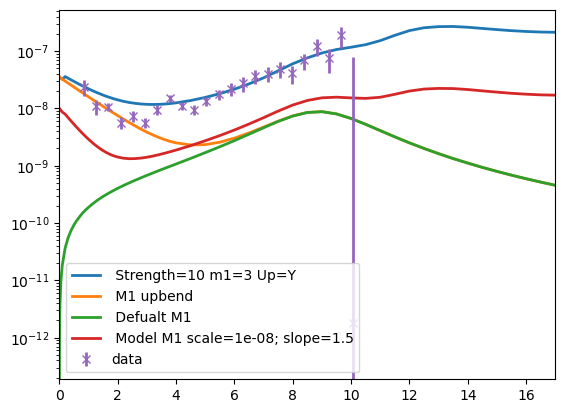

In [30]:
fig2 = plt.figure()
#plt.plot(energy_ysf_talys,(ysf_E1_talys+ysf_M1_talys),label=f' Strength=10 m1=3 Up=N',lw=2)
plt.plot(energy_ysf_up,(ysf_E1_up+ysf_M1_up),label=f' Strength=10 m1=3 Up=Y',lw=2)
plt.plot(energy_ysf_up,ysf_M1_up,label=f' M1 upbend',lw=2)
#plt.plot(energy_ysf_talys,ysf_E1_talys,label=f' Default E1',lw=2)
plt.plot(energy_ysf_talys,ysf_M1_talys,label=f' Defualt M1',lw=2)
plt.plot(energy_ysf_talys,(model_up+.078*ysf_E1_talys),label=f' Model M1 scale={scale}; slope={slope}',lw=2)
#plt.errorbar(model_energy,rand_ysf,yerr=model_err,fmt='o',label=f'Randomized Model ',lw=2)
plt.errorbar(energy_data,ysf_data_scaled,yerr=err_data_scaled,fmt='x',label=f'data',lw=2)
#plt.plot(sorted_photo['E'],sorted_photo['f1'],label='photo abs')
plt.xlim(0,17)
#plt.ylim(1e-9,1e-6)
plt.yscale("log")
plt.legend()
plt.show()

In [31]:
upper_fit_lim = 200
lower_fit_lim = 0

nan_mask = ~np.isnan(model_ysf)
erg_mask = (model_energy > lower_fit_lim) & (model_energy < upper_fit_lim)
test_mask = nan_mask & erg_mask  # Combine them!

energy_model = model_energy[test_mask]
ysf_model = model_ysf[test_mask]
error_model = model_err[test_mask]

data = [energy_model,ysf_model, error_model]

In [32]:
#Test version of ysf Likelihood function
def likely_ysf(params, data):
    energy_data,points, sigmas = data  # include energies now
    
    prop_ysf = shift_model(params, energy_data)
    model_mask = np.isfinite(prop_ysf)
    
    model_valid = prop_ysf[model_mask]
    points_valid = points[model_mask]
    sigmas_valid = sigmas[model_mask]
    
    assert model_valid.ndim == points_valid.ndim == sigmas_valid.ndim == 1
    
    resid = (points_valid - model_valid) / sigmas_valid
    likelihoodlog_val = -0.5 * ( np.sum(resid**2) + np.sum(np.log(2 * np.pi * sigmas_valid**2)) )
    return likelihoodlog_val,params

In [33]:
#Test ysf likelihood with random distributions
np.random.seed()
results = []

for i in range(10000):
    #parhaps use a cost function to minimize ask Chat
    a0_guess = np.random.uniform(.7,1.25)#w
    a1_guess = np.random.uniform(-4,4)#E
    a2_guess = np.random.uniform(.1,2)#f
    #print(f'w = {a0_guess}, E = {a1_guess}, f = {a2_guess}')
    llv = likely_ysf([a0_guess,a1_guess,a2_guess],data)
    #print (llv[0])
    if  np.isnan(llv[0]) != True and np.abs(llv[0]) != np.inf:
        if len(results) == 0:
            results.append(llv)
        elif results[0][0] < llv[0]:
            results[0] = llv
    else:
        continue


In [34]:
#lv = likely_ysf(w,E,f,data,err)
lv_ll,lv_pm = likely_ysf([w,E,f],data)

In [38]:
print(lv_ll)

1017.9629591082064


In [39]:
best_a0 = max(results)[1]
print(f'True w = {w}, E = {E}, f = {f}')

True w = 1, E = -3, f = 1


In [42]:
#best_model = cp_3D_plot(best_a0,best_a1,best_a2)
best_model = shift_model([best_a0[0],best_a0[1],best_a0[2]],energy_model)
guess_model = shift_model([w,E,f],energy_model)
#print(best_model)

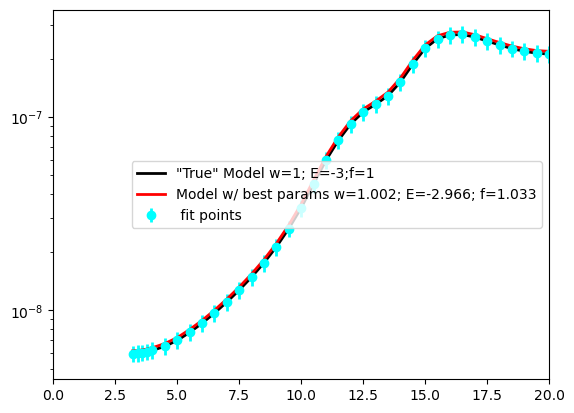

In [45]:
#Plot "best" parameter model to verify quality of functions
fig1 = plt.figure()
plt.plot(model_energy,model_ysf,color='black',label=f'"True" Model w={w}; E={E};f={f}',lw=2)

plt.errorbar(data[0],data[1],yerr=data[2],fmt='o',label=f' fit points ',lw=2,color = 'cyan')
plt.plot(energy_model,best_model,color='r',label=f'Model w/ best params w={best_a0[0]:.3f}; E={best_a0[1]:.3f}; f={best_a0[2]:.3f}',lw=2)
#plt.plot(data[0],new_best,label=r'asdf ',lw=2,color='peru')

plt.xlim(0,20)
#plt.ylim(1e-9,1e-6)
plt.yscale("log")
plt.legend()
plt.show()

In [47]:
'''
#Plot "best" parameter model to verify quality of functions
figgy = plt.figure()
plt.hlines(1,0,50,linestyle='dotted')
plt.plot(energy_ysf_talys,best_model/data[1],color='black',label=f'Ratio between fit and Model',lw=2)


#plt.xlim(40,55)
#plt.ylim(1e-9,1e-6)
#plt.yscale("log")
plt.legend()
plt.show()
'''

'\n#Plot "best" parameter model to verify quality of functions\nfiggy = plt.figure()\nplt.hlines(1,0,50,linestyle=\'dotted\')\nplt.plot(energy_ysf_talys,best_model/data[1],color=\'black\',label=f\'Ratio between fit and Model\',lw=2)\n\n\n#plt.xlim(40,55)\n#plt.ylim(1e-9,1e-6)\n#plt.yscale("log")\nplt.legend()\nplt.show()\n'

In [49]:
#full 3 param cov
def pres_mtx(sigmas):
    

    
    # ==== Build covariance matrix ====

    if len(sigmas) == 3:
        # ==== Set your correlations ====
        rho12 = 0.7   # correlation between param1 and param2
        rho13 = 0.   # correlation between param1 and param3
        rho23 = 0.  # correlation between param2 and param3
        
        sigma1,sigma2,sigma3 = sigmas
        cov = np.array([
            [sigma1**2,            rho12*sigma1*sigma2, rho13*sigma1*sigma3],
            [rho12*sigma1*sigma2,  sigma2**2,           rho23*sigma2*sigma3],
            [rho13*sigma1*sigma3,  rho23*sigma2*sigma3, sigma3**2          ]
            ])
    elif len(sigmas) == 2:
        # ==== Set your correlations ====
        rho12 = 0.0   # correlation between param1 and param2

        sigma1,sigma2= sigmas
        cov = np.array([
                [sigma1**2,  rho12*sigma1*sigma2],
                [rho12*sigma1*sigma2,  sigma2**2],
                ])
    elif len(sigmas)==4:
        # ==== Set your correlations ====
        rho12 = 0.0   # correlation between param1 and param2
        rho13 = 0.   # correlation between param1 and param3
        rho14 = 0.
        rho23 = 0.3  # correlation between param2 and param3
        rho24 = 0.7
        rho34 = 0.7
        sigma1,sigma2,sigma3,sigma4 = sigmas
        cov = np.array([
            [sigma1**2,            rho12*sigma1*sigma2, rho13*sigma1*sigma3, rho14*sigma1*sigma4],
            [rho12*sigma1*sigma2,  sigma2**2,           rho23*sigma2*sigma3, rho24*sigma2*sigma4],
            [rho13*sigma1*sigma3,  rho23*sigma2*sigma3, sigma3**2          , rho34*sigma3*sigma4],
            [rho14*sigma1*sigma4,  rho24*sigma2*sigma4, rho34*sigma3*sigma4,          sigma4**2 ]
            ])
    # check positive definiteness (required!)
    eigvals = np.linalg.eigvals(cov)
    if np.any(eigvals <= 0):
        raise ValueError("Covariance matrix is not positive-definite. Adjust σ or ρ values.")
    
    # ==== Compute precision matrix ====
    precision = np.linalg.inv(cov)
    
    print("Covariance matrix Σ:\n", cov)
    print("\nPrecision matrix Λ = Σ⁻¹:\n", precision)
    
    return precision

In [52]:
def likelihood_ysf(params,arguments): #returns e^-chi2
    data, model, sigmas = arguments
    likelihood_log_val=0
    
    for i in range(len(data[0])):
        resid = (points - true) / sigmas
        likelihood_log_val = -0.5 * np.sum(resid**2 + np.log(2*np.pi*sigmas**2))
  
    return np.exp(likelihood_log_val)

In [54]:
def E1_model(params,energy):
    w, E_shift, scale = params
    # Compute mapped energies for data grid
    mapped_energy = center_E + w * (energy - center_E) + E_shift

    # Interpolate from TALYS onto mapped energy positions
    new_E1 = np.interp(mapped_energy, energy_ysf_talys, ysf_E1_talys,
                       left=np.nan, right=np.nan)

    new_M1 = np.interp(mapped_energy, energy_ysf_talys, ysf_M1_talys,
                       left=np.nan, right=np.nan)

    # Combine components
    scaled = scale * new_E1 #+ new_M1   # OR exclude M1 if intended
    return scaled

In [56]:
def M1_model(params,energy): # upbend manipulation
    param0,param1,param2,param3 = params
    #param0 - upbendc; param1 - upbende; param2-upbendf. I may need to add a param4 - beta2 for deformation
    # new_f(M1) = upbendf * exp(-upbendc*abs(deformation) ) * exp(-upbende*Energy ) maybe???? TALYS 2.0 manual pg.56
    new_m1= param0*np.exp(-param1*energy)*np.exp(-param2*param3)

    int_m1 = np.interp(energy, energy_ysf_talys, ysf_M1_talys, left=np.nan, right=np.nan)
    return new_m1+int_m1

In [58]:
def E1_prior(params_vals,arguments):
    upper_limit = 10.
    w_low_limit = 0.
    E_low_limit = -10.
    f_low_limit = 0.1
    params0,params0_Cov_Inv_matrix=arguments

    # ----- HARD BOUNDARIES / HEAVYSIDE FUNCTIONS -----
    # If outside allowed region → impossible → log-prior = -∞
    if (np.any(params_vals) > upper_limit or 
        params_vals[0] < w_low_limit or
        params_vals[1] < E_low_limit or
        params_vals[2] <= f_low_limit
       ):
        return -np.inf
 # ----- GAUSSIAN LOG PRIOR -----
    mu = np.asarray(params_vals) - np.asarray(params0)
    d = len(mu)

    # Quadratic form
    quad = mu @ (params0_Cov_Inv_matrix @ mu)

    # log(det(inv_cov)) in a stable way
    sign, logdet_inv = np.linalg.slogdet(params0_Cov_Inv_matrix)
    if sign <= 0:
        return -np.inf   # inv_cov must be positive definite

    # Log probability of multivariate Gaussian
    log_prior = -0.5 * (d * np.log(2*np.pi) - logdet_inv + quad)

    return log_prior


In [60]:
def M1_prior(params_vals,arguments):
    #Talys 2.0 manual has no limit suggestions. I have let previous trials determine resonable ranges
    
    scale_limit = 1e-5 #scaling upbendf
    Enorm_limit = 10 #slope of M1? upbende
    bnorm_limit = 10 # ...idk. Not Used maybe abs(beta^2) normalization
    beta2_limit = 1.5 #beta2 is an absolute value
    params0,params0_Cov_Inv_matrix=arguments
    mu=np.array(params_vals)-np.array(params0)
    params_size=len(params_vals)  

    #if all(vals > upper_limit for vals in params_vals):
    #    return -np.inf
    if (params_vals[0] < 0 or np.abs(params_vals[0]) > scale_limit
       or params_vals[1] < 0 or params_vals[1] > Enorm_limit 
       or np.abs(params_vals[2]) > bnorm_limit
       or params_vals[3] < 0 or params_vals[3] > beta2_limit
       ):
        return -np.inf
 # ----- GAUSSIAN LOG PRIOR -----
    mu = np.asarray(params_vals) - np.asarray(params0)
    d = len(mu)

    # Quadratic form
    quad = mu @ (params0_Cov_Inv_matrix @ mu)

    # log(det(inv_cov)) in a stable way
    sign, logdet_inv = np.linalg.slogdet(params0_Cov_Inv_matrix)
    if sign <= 0:
        return -np.inf   # inv_cov must be positive definite

    # Log probability of multivariate Gaussian
    log_prior = -0.5 * (d * np.log(2*np.pi) - logdet_inv + quad)

    return log_prior

In [62]:
def loglikelihood_ysf(params, arguments):
    """
    Log-likelihood for gamma strength function (ySF).
    Combines M1 and E1 (from TALYS) components on the experimental grid.
    """
    data, model, sigmas = arguments
    energy_data, points = data

    # --- CASE 1: single callable model ---
    if callable(model):
        X1 = model(params, energy_data)
        
        if model == M1_model:
            E1_interp = np.interp(
                energy_data, energy_ysf_talys, ysf_E1_talys,
                left=np.nan, right=np.nan
            )
            valid_mask = np.isfinite(X1) & np.isfinite(E1_interp)
            observable = X1[valid_mask] + E1_interp[valid_mask]

        elif model == E1_model:
            M1_interp = np.interp(
                energy_data, energy_ysf_talys, ysf_M1_talys,
                left=np.nan, right=np.nan
            )
            valid_mask = np.isfinite(X1) & np.isfinite(M1_interp)
            observable = X1[valid_mask] + M1_interp[valid_mask]

        else:
            raise ValueError("Unknown single model type (expected M1_model or E1_model).")

    # --- CASE 2: list or tuple of two models ---
    elif isinstance(model, (list, tuple)) and len(model) == 2:
        # Evaluate both models
        params_E1 = params[:3]
        params_M1 = params[3:]
        E1 = model[0](params_E1, energy_data)
        M1 = model[1](params_M1, energy_data)

        valid_mask = np.isfinite(E1) & np.isfinite(M1)
        observable = M1[valid_mask] + E1[valid_mask]
    else:
        raise ValueError("Invalid 'model' argument: must be a function or a list of two functions.")

    # --- Likelihood computation ---
    #print(energy_data,energy_valid,observable)
    
    obs_valid = observable
    points_valid = points[valid_mask]
    sigmas_valid = sigmas[valid_mask]

    assert obs_valid.ndim == points_valid.ndim == sigmas_valid.ndim == 1

    resid = (points_valid - obs_valid) / sigmas_valid
    ll = -0.5 * (np.sum(resid**2) + np.sum(np.log(2 * np.pi * sigmas_valid**2)))

    return ll


In [64]:
def check_prior(prior,params_current,prior_arguments): 
    #check prior variable length and value
    #Directs code to the correct prior functions for the task
    
    if callable(prior):
        if prior == E1_prior:
            if len(prior_arguments[0]) > 3:
                raise ValueError("Too many parameters. E1 fitting accepts 3 parameters wtable,Etable, and ftable.")
            else:
                pri = prior(params_current,prior_arguments)
        elif prior == M1_prior:
            if len(prior_arguments[0]) > 4:
                raise ValueError("Too many parameters.M1 fitting accepts 2parameters: upbendc and upbende.")
            else:
                pri = prior(params_current,prior_arguments)
        else:
             raise ValueError("Unknown single model type (expected M1_prior or E1_prior).")
    elif isinstance(prior,(list,tuple)) and len(prior)== 2:
        E1_current = params_current[:3]
        M1_current = params_current[3:]
        w,E,f,c,s,r,b= prior_arguments[0]
        E1_pres,M1_pres = prior_arguments[1]
        E1_arguments = [w,E,f],E1_pres
        M1_arguments = [c,s,r,b],M1_pres
        
        if prior[0] != E1_prior or prior[1] != M1_prior:
            raise ValueError("Invalid 'prior' argument: E1_prior must be in postion {0} and M1_prior must be in postion {1}")
        elif len(prior_arguments[1]) != 2:
            raise ValueError("Invalid 'prior' argument: There must be two precision matrices. One for E1 fitting in postion {0} and another for M1 fitting in position {1}")
        else:
            pri = prior[0](E1_current,E1_arguments) + prior[1](M1_current,M1_arguments)
    else:
        raise ValueError("Invalid 'prior' argument: must be a function or a list of two functions.")   
    return pri

In [66]:
# Define the Metropolis algorithm
def metropolis(burn,data,sigma, prior,prior_arguments, likelihood,model,\
               num_iterations, step_size):
    
#   step_size should be a list the size of the parameters of the model
    likelihood_arguments=[data, model, sigma]
    initial_parameters=prior_arguments[0]
    
    #thermalizing
    burn_samples=burn

    # Set the initial state of the chain
    params_current=initial_parameters
    params_list=[]
    posterior_list=[]
    chi2=[]
    acceptance_times=0
    out = 0
    cov_step_size=np.diag(step_size)**2
    #cov_step_size = cov_mtx_2D(step_size[0],step_size[1],1,1)
    pri = check_prior(prior,params_current,prior_arguments)
    posterior_current=(likelihood(params_current,likelihood_arguments))+pri
    
    # Run the Metropolis-Hastings algorithm for burning
    print('Burn')
    
    for i in range(burn_samples):
        # Propose a new state for the chain
        #params_current[0] = 0
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        #params_proposed[2] = .5
        pri = check_prior(prior,params_proposed,prior_arguments)
        if pri != -np.inf:
            llh = likelihood(params_proposed,likelihood_arguments)
        else:
            llh = -np.inf
        posterior_proposed=llh+pri
        # Calculate the acceptance probability
        #scaled_factor = scale_by_digits(posterior_proposed,posterior_current)
        # ratio = np.exp((-np.abs(posterior_proposed)) - (-np.abs(posterior_current)))#/scaled_factor)   #posterior_proposed/posterior_current
        ratio = np.exp(((posterior_proposed)) - ((posterior_current)))#/scaled_factor)   #posterior_proposed/posterior_current
        if np.isnan(ratio) == True or np.abs(posterior_proposed) == np.inf:
            ratio = 0
        acceptance_prob = min(1, ratio )
        #print(f'i = {i},llh = {llh} params proposed = {params_proposed} {posterior_proposed},params current{params_current} {posterior_current}, acceptance prob = {acceptance_prob}')
      
        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed


    print('Calc')
    for i in range(num_iterations):
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        #params_proposed[0] = 0
        #params_proposed[0] = 2.3 * np.random.uniform(.9,1.1) #testing
        #params_proposed[2] = .5
        pri = check_prior(prior,params_proposed,prior_arguments)
        if pri != -np.inf:
            llh = likelihood(params_proposed,likelihood_arguments)
        else:
            llh = -np.inf
        posterior_proposed=llh+pri
        # Calculate the acceptance probability
        #scaled_factor = scale_by_digits(posterior_proposed,posterior_current)
        ratio = np.exp((posterior_proposed) - ((posterior_current)))#/scaled_factor)   #posterior_proposed/posterior_current
        if np.isnan(ratio) == True or np.abs(posterior_proposed) == np.inf:
            ratio = 0
        acceptance_prob = min(1, ratio)
        # Accept or reject the proposal
        #print(f'i = {i}, llh = {llh}, params proposed = {params_proposed} {posterior_proposed},params current{params_current} {posterior_current}, acceptance prob = {acceptance_prob}')
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed
            acceptance_times=acceptance_times+1
        #if ratio == -1:
        #    out=out+1
        # Store the current state
        if i%10 == 0:#introduce lag to reduce autocorrelation between succsessive params
            params_list.append(params_current)
            posterior_list.append(posterior_current)
            chi2.append(likelihood(params_current,likelihood_arguments))

    #Rule of thumb acceptance is around 50%. 
    #You could plot the accuracy of the estimations as a function of this rate, that would be interesting to see.
    
    print(f'Accepted {acceptance_times/num_iterations*100}%')
    print(f'Rejected {(1-(acceptance_times/num_iterations))*100}%')
    print(f'Outliers {out/num_iterations*100}%')
    return(np.array(params_list),np.array(posterior_list),np.array(chi2),acceptance_times/num_iterations*100)

#

In [68]:
Zn64_energy = np.array(Car64Zn['E'])
Zn64_ysf    = np.array(Car64Zn['f1'])
Zn64_error  = np.array(Car64Zn['df1'])

In [70]:
energy_full = np.append(energy_data,Zn64_energy)
ysf_full    = np.append(ysf_data_scaled,Zn64_ysf)
error_full  = np.append(err_data_scaled,Zn64_error)

In [72]:
#Make masks

energy_high = 10.
energy_low = 0.
data_mask = ysf_full > 1e-10
energy_mask = (energy_full>energy_low) & (energy_full<energy_high)
mask = data_mask & energy_mask
mask = np.ravel(mask)
masked_energy = energy_full[mask]
masked_data = ysf_full[mask]
masked_error = error_full[mask]


In [74]:
#Firestone R. 2021 The Origin of the Giant Dipole Resonance
#(6) E = 2*hbar*omega = 2(47.34+/- 0.27)(A^(-1/3) - A(-2/3))
A = 60
Ef = 2*(47.34)*(A**(-1/3) - A**(-2/3))
print(Ef)
Eguess = Ef-center_E
print(Eguess)


18.00706454857607
4.507064548576071


In [76]:
#Initialize params
a0,a1,a2 = 1.30,-0.52,0.78 #w,E,f
a3,a4,a5,a6 = 1e-8, 1, 1, 0 #scale, slope, renorm, abs_beta2

#E1 steps
a0_step     = 0.05
#a0_a1_ratio = 5/1.5 #Will change depeding on a0, a1 distributions
#a0_a2_ratio =1.5/1.2 #Will change depeding on a0, a2 distributions
a1_step = a0_step #* a0_a1_ratio
a2_step = a0_step #* a0_a2_ratio
E1_steps = [a0_step,a1_step,a2_step]

#M1 steps
a3_step = 1e-9
a4_step =  1e-6 
a5_step = a0
a6_step =  0.001
M1_steps = [a3_step,a4_step,a5_step,a6_step]

#All steps
all_steps = E1_steps+ M1_steps

#Precision Matrices - determine sigma and covarience of steps
precision_matrix_E1 = pres_mtx([1,1,1])
precision_matrix_M1 = pres_mtx([1,1,1,1])

#Prior Arguments
prior_arguments_E1=[[a0,a1,a2],precision_matrix_E1]
prior_arguments_M1=[[a3,a4],precision_matrix_M1]
prior_arguments_all = [[a0,a1,a2,a3,a4,a5,a6],[precision_matrix_E1,precision_matrix_M1]]
all_prior = [E1_prior,M1_prior]

#All models for E1+M1 fitting
all_model = [E1_model,M1_model]

Covariance matrix Σ:
 [[1.  0.7 0. ]
 [0.7 1.  0. ]
 [0.  0.  1. ]]

Precision matrix Λ = Σ⁻¹:
 [[ 1.96078431 -1.37254902  0.        ]
 [-1.37254902  1.96078431  0.        ]
 [ 0.          0.          1.        ]]
Covariance matrix Σ:
 [[1.  0.  0.  0. ]
 [0.  1.  0.3 0.7]
 [0.  0.3 1.  0.7]
 [0.  0.7 0.7 1. ]]

Precision matrix Λ = Σ⁻¹:
 [[ 1.          0.          0.          0.        ]
 [ 0.          2.27678571  0.84821429 -2.1875    ]
 [ 0.          0.84821429  2.27678571 -2.1875    ]
 [ 0.         -2.1875     -2.1875      4.0625    ]]


In [78]:
np.random.seed(142857)
#Data
data = [masked_energy,masked_data]
error = masked_error

#Performing the Metropolis sampling
burn = 100000
num_iter = 250000

start = time.time()
results_A=metropolis(burn,data,error,all_prior,prior_arguments_all,loglikelihood_ysf,all_model,num_iter,all_steps)
end = time.time()
total = end-start
minutes,seconds = divmod(total,60)
print(f"Elapsed Time {int(minutes)}:{seconds:.2f}")
all_chains =results_A[0]
all_chi2 = results_A[2]
print(all_chains)

Burn
Calc
Accepted 23.2604%
Rejected 76.7396%
Outliers 0.0%
Elapsed Time 0:51.50
[[ 0.86971211  0.22516937  0.53604339 ...  0.99993392  1.93088531
   0.19358773]
 [ 0.86971211  0.22516937  0.53604339 ...  0.99993392  1.93088531
   0.19358773]
 [ 0.91256287  0.3306277   0.57333932 ...  0.99993285  2.22593185
   0.19773011]
 ...
 [ 1.02917363 -0.2082426   1.03378598 ...  0.9995852   1.44606842
   0.16701509]
 [ 0.99678574 -0.20855065  1.01643353 ...  0.999585    0.82422393
   0.16914859]
 [ 0.9978395  -0.20107799  0.99784607 ...  0.99958463  1.4463264
   0.16706305]]


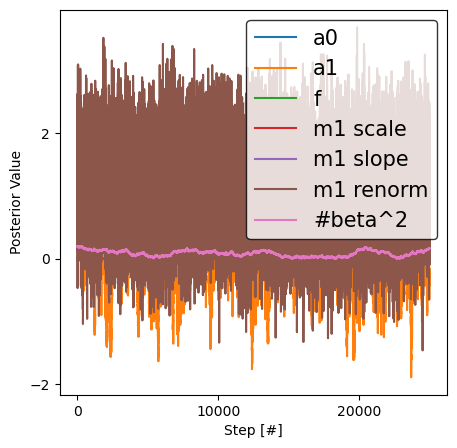

In [79]:
fig, ax = plt.subplots(figsize=(5,5),dpi=100)
ax.plot(np.linspace(0,len(all_chains),len(all_chains)),all_chains[:,0],label = 'a0')
ax.plot(np.linspace(0,len(all_chains),len(all_chains)),all_chains[:,1],label = 'a1')
ax.plot(np.linspace(0,len(all_chains),len(all_chains)),all_chains[:,2],label = 'f')
ax.plot(np.linspace(0,len(all_chains),len(all_chains)),all_chains[:,3],label = 'm1 scale')
ax.plot(np.linspace(0,len(all_chains),len(all_chains)),all_chains[:,4],label = 'm1 slope')
ax.plot(np.linspace(0,len(all_chains),len(all_chains)),all_chains[:,5],label = 'm1 renorm')
ax.plot(np.linspace(0,len(all_chains),len(all_chains)),all_chains[:,6],label = r'#beta^2')
plt.legend(fontsize=15,frameon=True, edgecolor='black')

#plt.xlim(0,2e4)
#plt.ylim(-1e08,1e08)
#ax.set_xlabel('Energy',fontsize=20)
#ax.set_ylabel('NLD',fontsize=20)
plt.xlabel("Step [#]")
plt.ylabel("Posterior Value")
plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
C:\Users\th3C0\AppData\Local\Temp\ipykernel_30560\125245500.py:10: SyntaxWarning: invalid escape sequence '\c'
  axs.set_ylabel('$\chi^2$',fontsize=20)


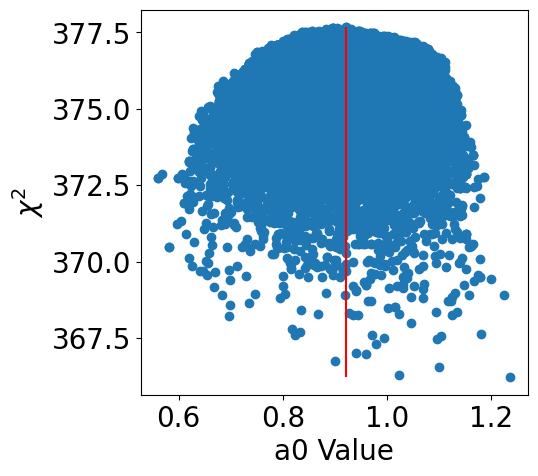

In [80]:
fig, axs = plt.subplots(figsize=(5,5),dpi=100)
axs.scatter(all_chains[:,0], results_A[1])
axs.vlines(all_chains[np.argmax(results_A[1])][0],max(results_A[1]),min(results_A[1]),color = 'r')
#plt.legend(fontsize=15,frameon=True, edgecolor='black')
#plt.xlim(-2,0.001)
#plt.ylim(-6,-5.5)
#plt.yscale("log")

axs.set_xlabel('a0 Value',fontsize=20)
axs.set_ylabel('$\chi^2$',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
C:\Users\th3C0\AppData\Local\Temp\ipykernel_30560\994568061.py:10: SyntaxWarning: invalid escape sequence '\c'
  axs.set_ylabel('$\chi^2$',fontsize=20)


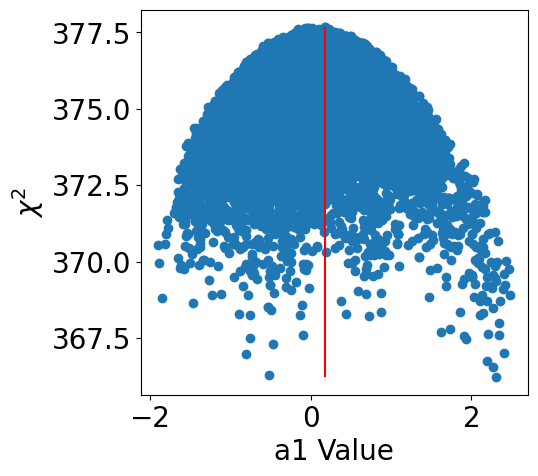

In [81]:
fig, axs = plt.subplots(figsize=(5,5),dpi=100)
axs.scatter(all_chains[:,1], results_A[1])
axs.vlines(all_chains[np.argmax(results_A[1])][1],max(results_A[1]),min(results_A[1]),color = 'r')
#plt.legend(fontsize=15,frameon=True, edgecolor='black')
#plt.xlim(-2,0.001)
#plt.ylim(-1660,-1640)
#plt.yscale("log")

axs.set_xlabel('a1 Value',fontsize=20)
axs.set_ylabel('$\chi^2$',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
C:\Users\th3C0\AppData\Local\Temp\ipykernel_30560\3437023712.py:10: SyntaxWarning: invalid escape sequence '\c'
  axs.set_ylabel('$\chi^2$',fontsize=20)


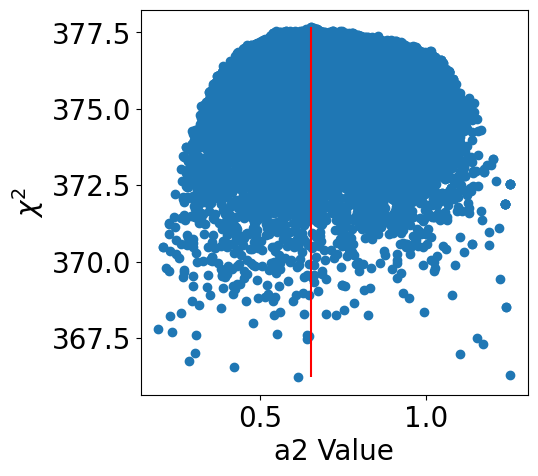

In [82]:
fig, axs = plt.subplots(figsize=(5,5),dpi=100)
axs.scatter(all_chains[:,2], results_A[1])
axs.vlines(all_chains[np.argmax(results_A[1])][2],max(results_A[1]),min(results_A[1]),color = 'r')
#plt.legend(fontsize=15,frameon=True, edgecolor='black')
#plt.xlim(-2,0.001)
#plt.ylim(-.01,.01)
#plt.yscale("log")

axs.set_xlabel('a2 Value',fontsize=20)
axs.set_ylabel('$\chi^2$',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

In [83]:
#print(f'Model w = {w},E = {E},f = {f}')
best = all_chains[np.argmax(all_chi2)]

#print(f'mean w = {np.mean(all_chains[:,0])}, E = {np.mean(all_chains[:,1])},f = {np.mean(all_chains[:,2])}')
#print(f'median w ={np.median(all_chains[:,0])}, E = {np.median(all_chains[:,1])}, f = {np.median(all_chains[:,2])}')
print(f'mean w = {np.mean(all_chains[:,0])}, E = {np.mean(all_chains[:,1])}')
print(f'median w ={np.median(all_chains[:,0])}, E = {np.median(all_chains[:,1])}')
print(f'best {best}, chi2 = {max(all_chi2)}')


mean w = 0.9233208257370982, E = 0.030754045829283268
median w =0.9302130056051152, E = 0.01411292437522426
best [1.07436369e+00 2.33619930e+00 4.45713547e-01 2.55656943e-08
 9.99778411e-01 3.59529113e-01 2.35519586e-02], chi2 = 385.50367594019195


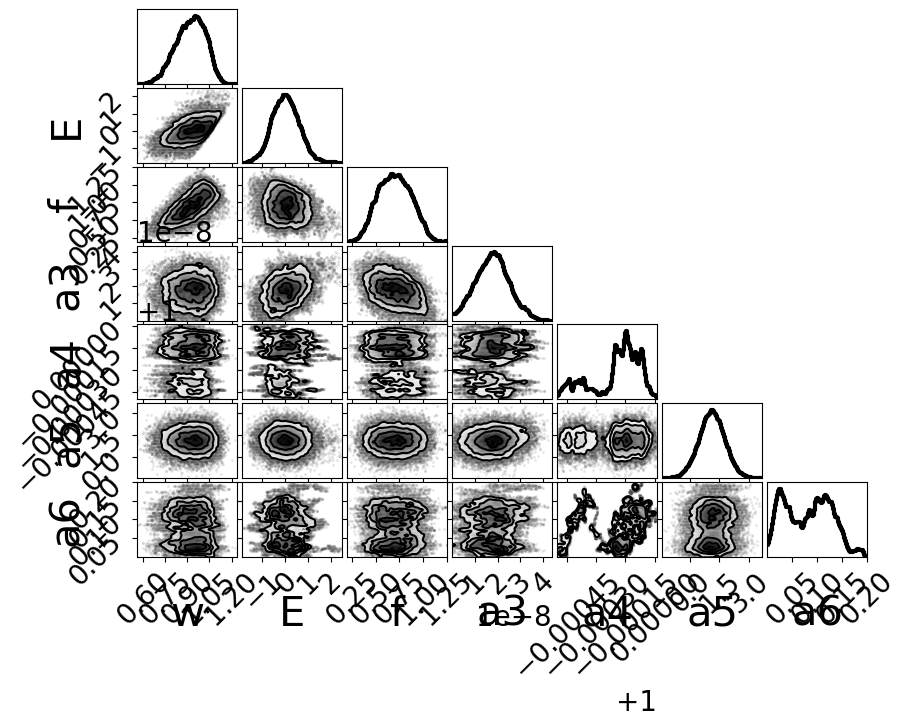

In [84]:
figure = corner.corner(all_chains,
    labels=[r'w',r'E',r'f',r'a3',r'a4',r'a5',r'a6'],
    labelpad=0.2,
                       bins=100,
    label_kwargs={"fontsize":30},
                      hist_kwargs= {"linewidth":3},
    quantiles=None
                        , truth_color='b'
                       ,
    smooth=(1.7)
                       ,
    smooth1d=1.0
                      )


width = 8
height = 6
#figure.vlines(0,-5,0,color = 'r')
figure.set_size_inches(width, height)
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)


In [155]:
#Use Bayesian Information Criterion to Determine number of clusters
bics = []
models = []
for k in range (1,21): # k is how many clusters are assumed to be in the parameter space (number of gaussian components)
    gmm =  GaussianMixture(n_components=k, covariance_type='full',random_state=0)#cov_type = full means each component has its own full cov matrix, allows clusters to be any ellipsoidal shape
    gmm.fit(all_chains)
    bics.append(gmm.bic(all_chains))
    models.append(gmm)
best_k = np.argmin(bics)
best_gmm = models[best_k]
print(bics)
print(f'Best number of clusters (lowest BIC) = {best_k+1}')

labels = best_gmm.predict(all_chains) #labels cp pairs from 0 to besk_k

[-632894.7787371367, -635760.2649449666, -635695.6157414041, -637046.5282257359, -636871.8440975999, -636523.9510799869, -636469.1165420832, -636316.4328409457, -636687.846958859, -636457.5937795752, -636397.1322758123, -636333.19575411, -636194.3716329866, -636007.3202657404, -635789.8137791317, -635649.5432333717, -635426.3790868818, -635267.3622513649, -635289.2063384095, -635103.8108516163]
Best number of clusters (lowest BIC) = 4


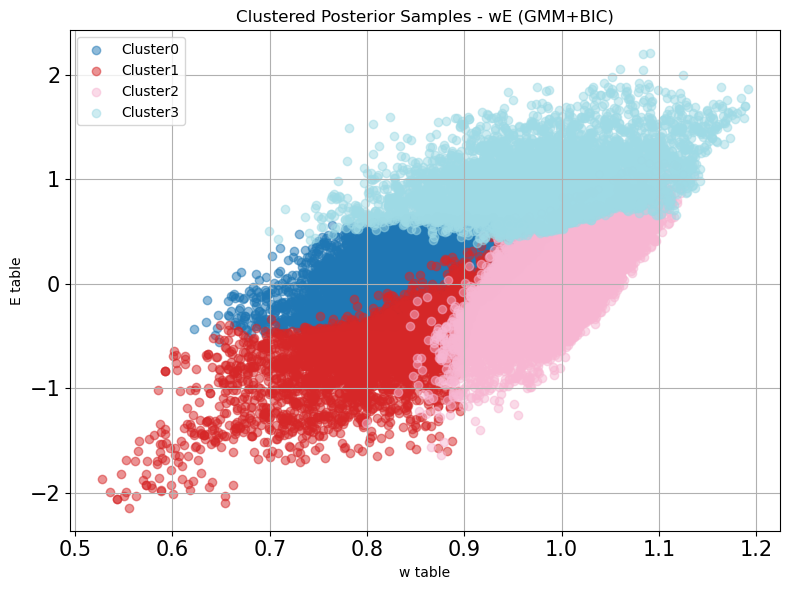

In [157]:
#Visualize clusters in param space
colors01 = plt.get_cmap("tab20", best_k + 1).colors
plt.figure(figsize=(8,6))
for i in range(best_k+1):
    cluster_samples = all_chains[labels == i]
    plt.scatter(cluster_samples[:,0],cluster_samples[:,1], label=f'Cluster{i}',color = colors01[i], alpha = .5)
plt.xlabel("w table")
plt.ylabel("E table")
plt.title('Clustered Posterior Samples - wE (GMM+BIC)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

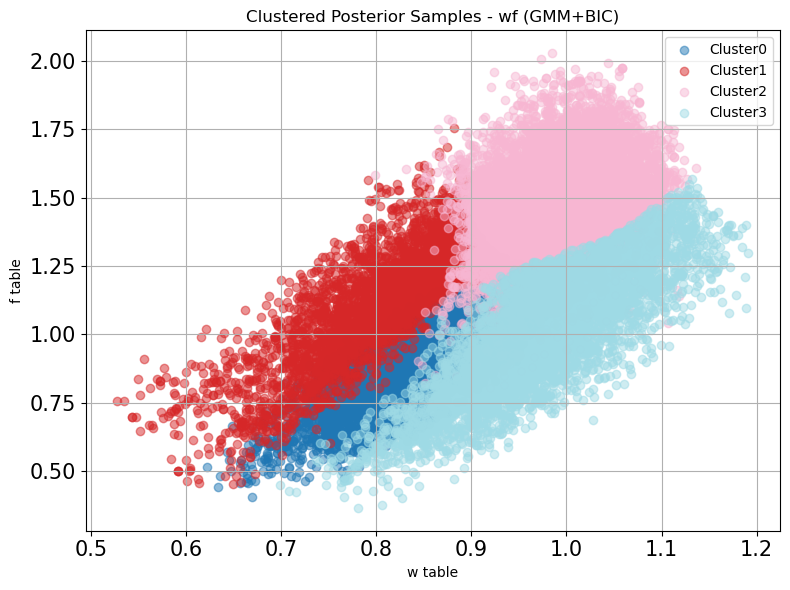

In [159]:
#Visualize clusters in param space
colors02 = plt.get_cmap("tab20", best_k + 1).colors
plt.figure(figsize=(8,6))
for i in range(best_k+1):
    cluster_samples = all_chains[labels == i]
    plt.scatter(cluster_samples[:,0],cluster_samples[:,2], label=f'Cluster{i}', alpha = .5,color = colors02[i])
plt.xlabel("w table")
plt.ylabel("f table")
plt.title('Clustered Posterior Samples - wf (GMM+BIC)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

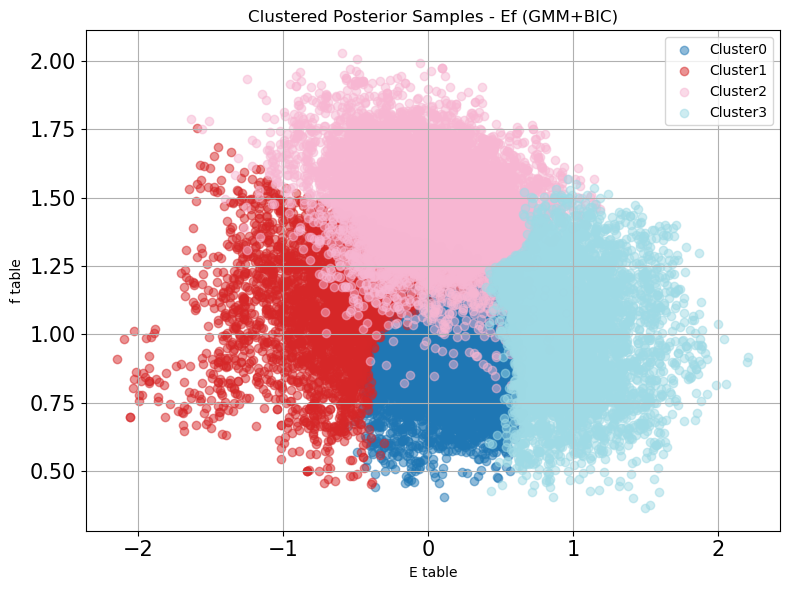

In [161]:
#Visualize clusters in param space
colors12 = plt.get_cmap("tab20", best_k + 1).colors
plt.figure(figsize=(8,6))
for i in range(best_k+1):
    cluster_samples = all_chains[labels == i]
    plt.scatter(cluster_samples[:,1],cluster_samples[:,2], label=f'Cluster{i}', alpha = .5,color = colors12[i])
plt.xlabel("E table")
plt.ylabel("f table")
plt.title('Clustered Posterior Samples - Ef (GMM+BIC)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The various colors show how GMM divided posterior (corner plot) into multiple regions. 

In [164]:
def plot_gmm_ellipses(gmm, ax, colors):
    for i, (mean, cov) in enumerate(zip(gmm.means_, gmm.covariances_)):
        v, w = np.linalg.eigh(cov)
        v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
        u = w[0] / np.linalg.norm(w[0])

        angle = np.degrees(np.arctan2(u[1], u[0]))
        ell = Ellipse(xy=mean, width=v[0], height=v[1], angle=angle, color=colors[i], alpha=1)
        ax.add_patch(ell)

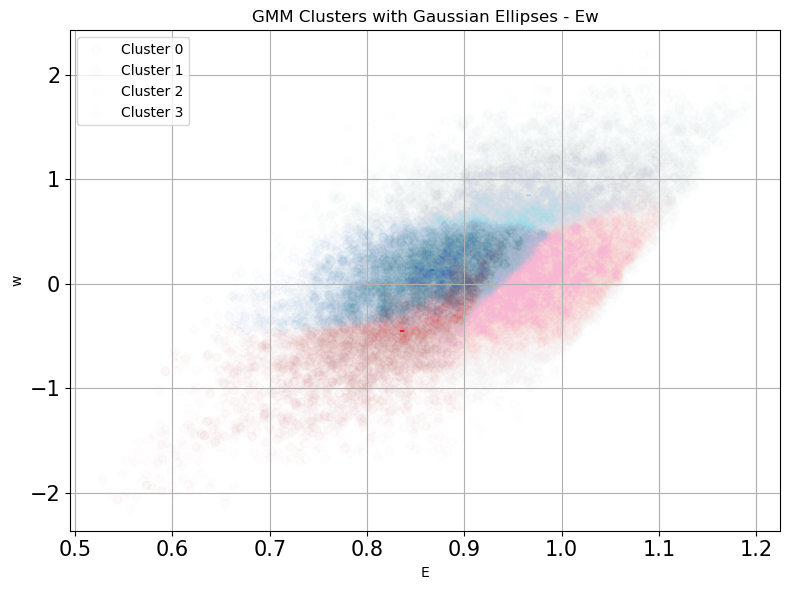

In [166]:

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(best_k + 1):
    cluster_samples = all_chains[labels == i]
    ax.scatter(cluster_samples[:, 0], cluster_samples[:, 1], label=f"Cluster {i}", alpha=0.01, color=colors01[i])

plot_gmm_ellipses(best_gmm, ax, colors01)

ax.set_xlabel("E")
ax.set_ylabel("w")
ax.set_title("GMM Clusters with Gaussian Ellipses - Ew")
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [85]:
def E1_plot(params,energy=energy_ysf_talys):
    w, E_shift, scale = params

    # Compute mapped energies for data grid
    mapped_energy = center_E + w * (energy - center_E) + E_shift

    # Interpolate from TALYS onto mapped energy positions
    new_E1 = np.interp(mapped_energy, energy_ysf_talys, ysf_E1_talys,
                       left=np.nan, right=np.nan)

    # Combine components
    scaled = scale * new_E1 #+ new_M1   # OR exclude M1 if intended
    
    return scaled

In [86]:
def M1_plot(param,energy=energy_ysf_talys):
    param0,param1,param2,param3 = param

    #param0 - upbendc; param1 - upbende; param2-upbendf. I may need to add a param4 - beta2 for deformation
    # new_f(M1) = upbendf * exp(-upbendc*abs(deformation) ) * exp(-upbende*Energy ) maybe???? TALYS 2.0 manual pg.56
    new_m1= param0*np.exp(-param1*energy)*np.exp(-param2*param3)

    #int_m1 = np.interp(energy_ysf_talys, energy, new_m1,, left=np.nan, right=np.nan)
    #int_e1 = np.interp(energy, energy_ysf_talys, ysf_E1_talys, left=np.nan, right=np.nan)
    return new_m1


In [87]:
rng = np.random.default_rng()
alpha_rand = rng.choice(all_chains,(int(len(all_chains)*.1)),replace=False)

E1 

In [89]:
func_rand_E1 =[E1_plot([alpha[0],alpha[1],alpha[2]]) for alpha in alpha_rand]
#print(alpha_rand[0])
my_guess = E1_plot([w,E,f])
mean_E1 = E1_plot([np.mean(all_chains[:,0]),np.mean(all_chains[:,1]),np.mean(all_chains[:,2])])
med_E1 = E1_plot([np.median(all_chains[:,0]),np.median(all_chains[:,1]),np.median(all_chains[:,2])])
best_bayes_E1 = E1_plot([best[0],best[1],best[2]])
#func_rand_E1 = np.array([f[1] for f in func_rand])
#func_rand = np.array(func_rand)

In [90]:
print(type(func_rand_E1))
print(len(func_rand_E1))
print(func_rand_E1[100])
types = [type(f) for f in func_rand_E1]
unique_types = set(types)
print("Unique types in func_rand:", unique_types)

shapes = [np.shape(f) for f in func_rand_E1]
unique_shapes = set(shapes)
print("Unique shapes in func_rand:", unique_shapes)

# Inspect a few problematic entries
for i, s in enumerate(shapes[:10]):
    if s != (13,):
        print(f"func_rand[{i}] shape = {s}")


<class 'list'>
2500
[           nan            nan            nan            nan
            nan            nan 0.00000000e+00 0.00000000e+00
 5.62200171e-09 5.90834136e-09 5.89976527e-09 5.90652648e-09
 5.90834136e-09 5.91558462e-09 5.93188603e-09 5.95089087e-09
 5.97580614e-09 6.00431342e-09 6.03784256e-09 6.07585225e-09
 6.11386195e-09 6.15924971e-09 6.21626425e-09 6.27327880e-09
 6.33264954e-09 6.40107843e-09 6.56511064e-09 6.75542873e-09
 6.98348691e-09 7.23892174e-09 7.51284973e-09 7.80489402e-09
 8.12284731e-09 8.47532347e-09 8.85712806e-09 9.27902684e-09
 1.05131291e-08 1.20024933e-08 1.38749525e-08 1.62842043e-08
 1.95357028e-08 2.40982937e-08 3.06773818e-08 4.03566209e-08
 5.31760873e-08 6.73516655e-08 8.27455928e-08 9.67612221e-08
 1.08019029e-07 1.21033865e-07 1.42193077e-07 1.74633898e-07
 2.11883046e-07 2.42065163e-07 2.58946023e-07 2.64714505e-07
 2.61424842e-07 2.51924554e-07 2.40951804e-07 2.30884869e-07
 2.22406355e-07 2.16348409e-07 2.12354541e-07 2.11078116e-07
 2.1

M1

In [92]:
func_rand_M1 =[M1_plot([alpha[3],alpha[4],alpha[5],alpha[6]]) for alpha in alpha_rand]
#print(alpha_rand[0])
my_guess_M1 = M1_plot([a3,a4,a5,a6])
mean_M1 = M1_plot([np.mean(all_chains[:,3]),np.mean(all_chains[:,4]),np.mean(all_chains[:,5]),np.mean(all_chains[:,6])])
med_M1 = M1_plot([np.median(all_chains[:,3]),np.median(all_chains[:,4]),np.median(all_chains[:,5]),np.median(all_chains[:,6])])
best_bayes_M1 = M1_plot([best[3],best[4],best[5],best[6]])
#func_rand_E1 = np.array([f[1] for f in func_rand])
#func_rand = np.array(func_rand)

In [93]:
print(type(func_rand_M1))
print(len(func_rand_M1))
print(func_rand_M1[0])
types = [type(f) for f in func_rand_M1]
unique_types = set(types)
print("Unique types in func_rand:", unique_types)

shapes = [np.shape(f) for f in func_rand_M1]
unique_shapes = set(shapes)
print("Unique shapes in func_rand:", unique_shapes)

# Inspect a few problematic entries
for i, s in enumerate(shapes[:10]):
    if s != (13,):
        print(f"func_rand[{i}] shape = {s}")


<class 'list'>
2500
[2.06222498e-08 2.06016414e-08 2.05399397e-08 2.04375139e-08
 2.02341919e-08 1.96362823e-08 1.86787698e-08 1.69015400e-08
 1.52934084e-08 1.38382857e-08 1.25216137e-08 1.13302191e-08
 1.02521822e-08 9.27671731e-09 8.39406504e-09 7.59539452e-09
 6.87271515e-09 6.21879659e-09 5.62709645e-09 5.09169483e-09
 4.60723510e-09 4.16887027e-09 3.77221457e-09 3.41329949e-09
 3.08853412e-09 2.79466921e-09 2.28816019e-09 1.87345144e-09
 1.53390497e-09 1.25589829e-09 1.02827786e-09 8.41911610e-10
 6.89322593e-10 5.64388983e-10 4.62098483e-10 3.78347229e-10
 2.29498892e-10 1.39210063e-10 8.44424193e-11 5.12213127e-11
 3.10699633e-11 1.88465030e-11 1.14319631e-11 6.93443132e-12
 4.20630624e-12 2.55147269e-12 1.54767925e-12 9.38795497e-13
 5.69457130e-13 3.45422857e-13 2.09527537e-13 1.27095784e-13
 7.70941069e-14 4.67639533e-14 2.83662062e-14 1.72064506e-14
 1.04371357e-14 6.33098618e-15 3.84026684e-15 2.32943952e-15
 1.41299777e-15 8.57100033e-16 5.19902073e-16 3.15363615e-16
 1.9

Plotting

In [95]:
lower_E1 = np.percentile(func_rand_E1, 2.5, axis = 0)
median_E1 = np.percentile(func_rand_E1, 50, axis = 0)
upper_E1 = np.percentile(func_rand_E1, 97.5, axis = 0)

In [96]:
lower_M1 = np.percentile(func_rand_M1, 2.5, axis = 0) + ysf_M1_talys
median_M1 = np.percentile(func_rand_M1, 50, axis = 0) + ysf_M1_talys
upper_M1 = np.percentile(func_rand_M1, 97.5, axis = 0)+ ysf_M1_talys

In [97]:
#M1_model([1e-7,1],energy_ysf_talys)+ysf_total

In [98]:
lower = lower_E1 + lower_M1
median = median_E1 + median_M1
upper = upper_E1 + upper_M1

In [99]:
med = med_E1 + med_M1
mean = mean_E1 + mean_M1
best_bayes = best_bayes_E1 + best_bayes_M1

In [100]:
upper_E1

array([           nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan, 6.09903168e-09, 6.11384588e-09,
       6.12614906e-09, 6.13946395e-09, 6.17347725e-09, 6.21373774e-09,
       6.24794062e-09, 6.29262991e-09, 6.34451828e-09, 6.41049236e-09,
       6.48002461e-09, 6.55697376e-09, 6.74011938e-09, 6.96598052e-09,
       7.21634718e-09, 7.50153606e-09, 7.80602093e-09, 8.15436229e-09,
       8.52519636e-09, 8.92529219e-09, 9.37381395e-09, 9.87463514e-09,
       1.13544223e-08, 1.33662847e-08, 1.63602425e-08, 2.07220965e-08,
       2.65845611e-08, 3.40011602e-08, 4.34315945e-08, 5.54199190e-08,
       6.90935559e-08, 8.29794535e-08, 9.59534863e-08, 1.10345650e-07,
       1.32665393e-07, 1.64580854e-07, 1.97263010e-07, 2.25751607e-07,
       2.46083082e-07, 2.61066352e-07, 2.69701862e-07, 2.69943257e-07,
      

In [101]:
#match_mask = np.isin(data[0],best_beyes[0])
energy_final = energy_ysf_talys

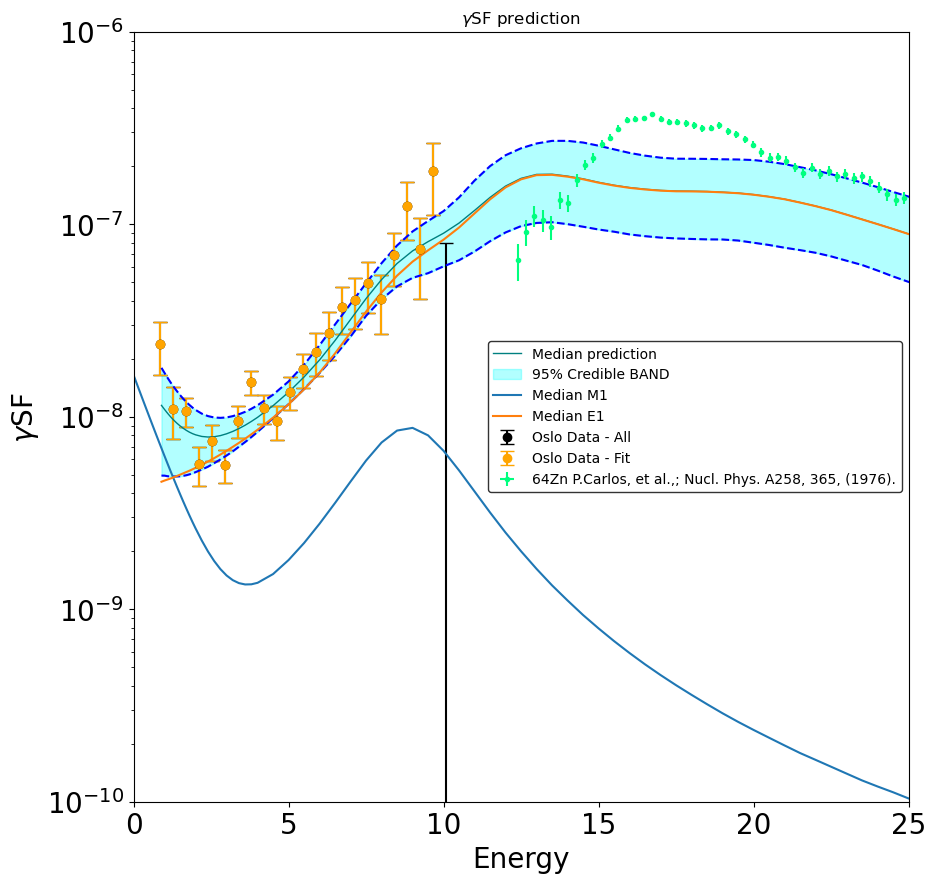

In [127]:
np.random.seed(142857)
fig, ax = plt.subplots(figsize=(10,10),dpi=100)
prediction_color_number=4

ax.errorbar(energy_data,ysf_data_scaled, yerr=err_data_scaled, fmt='o',color='black', capsize=5,label='Oslo Data - All')
ax.errorbar(data[0],data[1], yerr=error, fmt='o',color='orange', capsize=5,label='Oslo Data - Fit')

#compare model output  with talys energy not data energy
#we want to see how model points compare to data
ax.plot(energy_final, median, color='teal',linestyle='-' ,linewidth=1,label='Median prediction') 
ax.plot(energy_final, lower, color='blue',linestyle='dashed')
ax.plot(energy_final, upper, color='blue',linestyle='dashed')
ax.fill_between(energy_final, lower, upper, color='cyan', alpha=0.3,label='95% Credible BAND')

#If you want to see the true function that generated these, uncomment the following line
#ax.plot(new_energy,new_nld, label='True Function',color='g', alpha=0.6)


#ax.plot(energy_final,med,color='peru',label='Med')
#ax.plot(energy_final,mean,color='brown',label='Mean')
#ax.plot(energy_final,best_bayes,color='deepskyblue',label=r'Best $\chi^2$')
#ax.plot(energy_final,my_guess,label=r'guess')
ax.plot(energy_final,median_M1,label='Median M1')
ax.plot(energy_final,median_E1,label='Median E1')
#Other Data
#photo abs
#plt.errorbar(Cla64Zn['E'],Cla64Zn['f1'], fmt = '.', xerr = Cla64Zn['dE'], yerr = Cla64Zn['df1'], label = r' G.E.Clark, et al., J,NP/A, 213, 358, (1973)', color = 'chartreuse')
#plt.errorbar(Rod64Zn['E'],Rod64Zn['f1'], fmt = '.', xerr = Rod64Zn['dE'], yerr = Rod64Zn['df1'], label = r' T.E.Rodrigues, et al.,; Phys.Rev. C 68, 014618(2003)', color = 'forestgreen')
plt.errorbar(Car64Zn['E'],Car64Zn['f1'], fmt = '.', xerr = Car64Zn['dE'], yerr = Car64Zn['df1'],label = r'64Zn P.Carlos, et al.,; Nucl. Phys. A258, 365, (1976).', color = 'springgreen')
'''
#Traditional Oslo
plt.errorbar(LaBr56Fe['Eg(MeV)'],LaBr56Fe['f(MeV^-3)'], fmt = '-', yerr = LaBr56Fe['df(MeV^-3)'],label = r'56Fe LaBr3 A.C.Larsen et al., J. Phys. G: Nucl. Part. Phys. 44, 064005 (2017)', color = 'violet')
plt.errorbar(LaBr57Fe['Eg(MeV)'],LaBr57Fe['f(MeV^-3)'], fmt = 'x', yerr = LaBr57Fe['df(MeV^-3)'],label = r'57Fe LaBr3 A.C.Larsen et al., J. Phys. G: Nucl. Part. Phys. 44, 064005 (2017)', color = 'grey')
plt.errorbar(NaI56Fe['Eg(MeV)'],NaI56Fe['f(MeV^-3)'], fmt = 'd', yerr = NaI56Fe['df(MeV^-3)'],label = r'56Fe NaI A.C.Larsen et al., J. Phys. G: Nucl. Part. Phys. 44, 064005 (2017)', color = 'darkviolet')
plt.errorbar(NaI57Fe['Eg(MeV)'],NaI57Fe['f(MeV^-3)'], fmt = 'h', yerr = NaI57Fe['df(MeV^-3)'],label = r'57Fe NaI A.C.Larsen et al., J. Phys. G: Nucl. Part. Phys. 44, 064005 (2017)', color = 'silver')
plt.errorbar(CC64Ni['Eg(MeV)'],CC64Ni['f(MeV^-3)'], fmt = 'v', yerr = CC64Ni['f_err(MeV^-3)'],label = r'64Ni L. Crespo Campo et al., Phys. Rev.94, 044321 (2016)', color = 'saddlebrown')
plt.fill_between(CC64Ni['Eg(MeV)'],CC64Ni['f_low(MeV^-3)'], CC64Ni['f_high(MeV^-3)'], label = r'64Ni Error', color = 'chocolate',alpha=.2)
'''
#Shape Method
#plt.errorbar(W56Fe)

plt.legend(fontsize=10,frameon=True, edgecolor='black')

plt.xlim(0,25)
plt.ylim(1e-10,1e-6)
plt.yscale("log")
ax.set_title(r'$\gamma$SF prediction')
ax.set_xlabel('Energy',fontsize=20)
ax.set_ylabel(r'$\gamma$SF',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

In [192]:
#df_output = pd.DataFrame({'f_table (a0)':all_chains[:,0],'E_table (a1)':all_chains[:,1], 'w_table (a1)':all_chains[:,2], 'LogLikelihood':all_chi2})
#df_output.to_csv('Bayes_testing_ysf_output_data.csv', index=True)